# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

This project investigates the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

The goal is to identify patterns between market sentiment and profitability, evaluate trading behavior under different sentiment regimes, and derive actionable insights for sentiment-driven trading strategies.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Dataset Overview

## Fear & Greed Index Dataset

Columns:
- timestamp
- value
- classification
- date

This dataset represents Bitcoin market sentiment ranging from Extreme Fear to Extreme Greed.

## Hyperliquid Historical Trading Dataset

Key Columns:
- Account
- Coin
- Execution Price
- Size USD
- Side
- Timestamp IST
- Closed PnL

This dataset contains over 211,000 trading records from Hyperliquid traders.

In [5]:
fear_greed = pd.read_csv('../data/fear_greed_index.csv')
trades = pd.read_csv('../data/historical_data.csv')

In [6]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
print("Fear & Greed Shape:", fear_greed.shape)
print("Trader Data Shape:", trades.shape)

print("\nFear & Greed Columns:")
print(fear_greed.columns.tolist())

print("\nTrader Columns:")
print(trades.columns.tolist())

Fear & Greed Shape: (2644, 4)
Trader Data Shape: (211224, 16)

Fear & Greed Columns:
['timestamp', 'value', 'classification', 'date']

Trader Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


# Methodology

1. Data Cleaning
2. Date Standardization
3. Dataset Integration
4. Feature Engineering
5. Exploratory Data Analysis
6. Profitability Analysis
7. Win Rate Analysis
8. Statistical Testing
9. Insight Generation

In [8]:
print("Fear & Greed Missing Values")
print(fear_greed.isnull().sum())

print("\nTrader Missing Values")
print(trades.isnull().sum())

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [13]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

trades['date'] = pd.to_datetime(trades['date'])

In [14]:
trades[['Timestamp IST']].head()

,Timestamp IST
0,2024-12-02 22:50:00
1,2024-12-02 22:50:00
2,2024-12-02 22:50:00
3,2024-12-02 22:50:00
4,2024-12-02 22:50:00


In [15]:
merged = pd.merge(
    trades,
    fear_greed[['date','classification','value']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)

Merged Shape: (211224, 19)


In [16]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [17]:
print(
    merged[['date','classification','value']]
    .head()
)

        date classification  value
0 2024-12-02  Extreme Greed   80.0
1 2024-12-02  Extreme Greed   80.0
2 2024-12-02  Extreme Greed   80.0
3 2024-12-02  Extreme Greed   80.0
4 2024-12-02  Extreme Greed   80.0


In [18]:
merged['Profit_Flag'] = np.where(
    merged['Closed PnL'] > 0,
    1,
    0
)

In [19]:
merged[['Closed PnL','Profit_Flag']].head()

,Closed PnL,Profit_Flag
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [20]:
avg_profit = merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(
    ascending=False
)

print(avg_profit)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


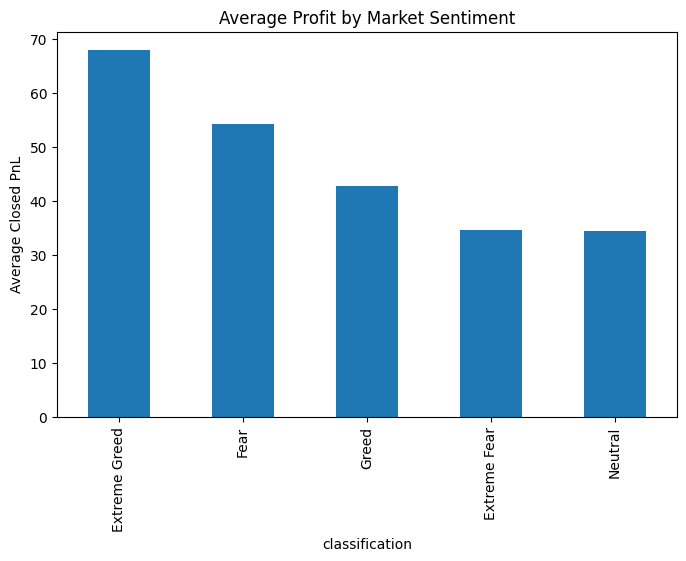

In [79]:
plt.figure(figsize=(8,5))

avg_profit.plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.savefig(
    '../outputs/figures/average_profit_by_Market_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
total_profit = merged.groupby(
    'classification'
)['Closed PnL'].sum().sort_values(
    ascending=False
)

print(total_profit)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


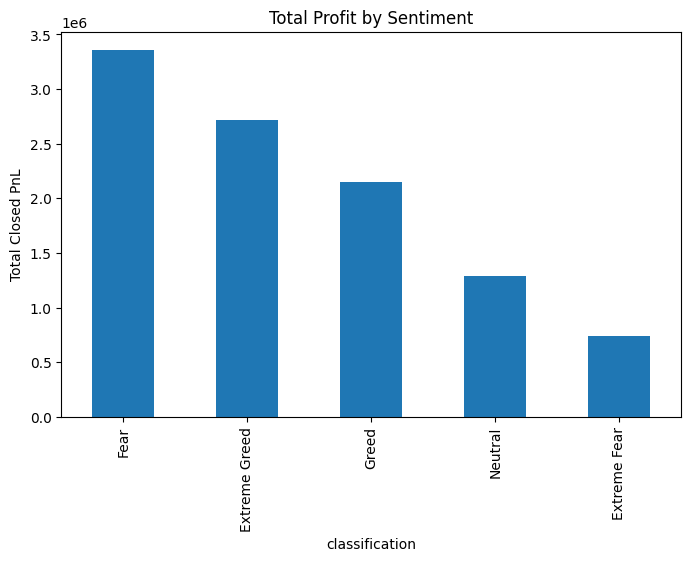

In [80]:
plt.figure(figsize=(8,5))

total_profit.plot(kind='bar')

plt.title('Total Profit by Sentiment')
plt.ylabel('Total Closed PnL')
plt.savefig(
    '../outputs/figures/total_profit_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [24]:
win_rate = merged.groupby(
    'classification'
)['Profit_Flag'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Profit_Flag, dtype: float64


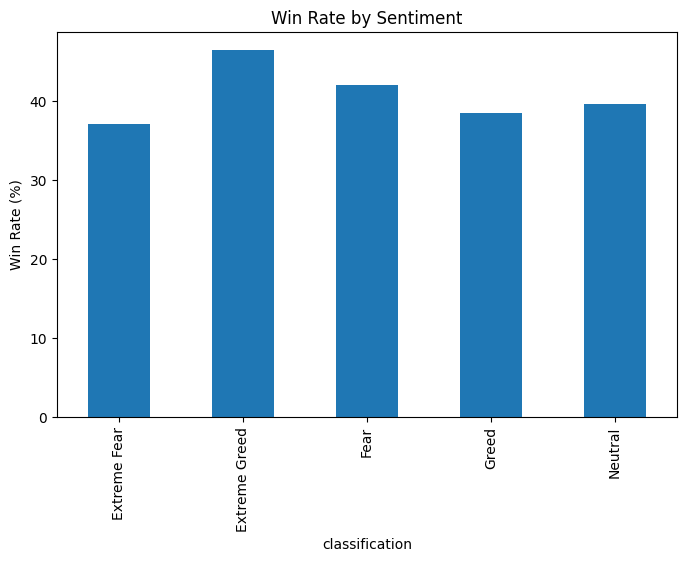

In [81]:
plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate (%)')
plt.savefig(
    '../outputs/figures/win_rate_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [26]:
volume = merged.groupby(
    'classification'
)['Size USD'].mean()

print(volume)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


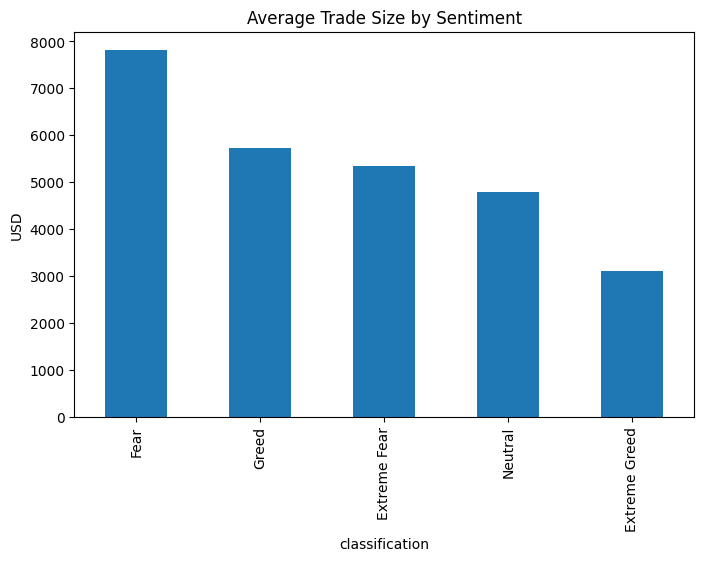

In [82]:
plt.figure(figsize=(8,5))

volume.plot(kind='bar')

plt.title('Average Trade Size by Sentiment')
plt.ylabel('USD')
plt.savefig(
    '../outputs/figures/Average_trade_size_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [28]:
side_profit = merged.groupby(
    ['classification','Side']
)['Closed PnL'].mean().reset_index()

print(side_profit)

  classification  Side  Closed PnL
0   Extreme Fear   BUY   34.114627
1   Extreme Fear  SELL   34.980106
2  Extreme Greed   BUY   10.498927
3  Extreme Greed  SELL  114.584643
4           Fear   BUY   63.927104
5           Fear  SELL   45.049641
6          Greed   BUY   25.002302
7          Greed  SELL   59.691091
8        Neutral   BUY   29.227429
9        Neutral  SELL   39.456408


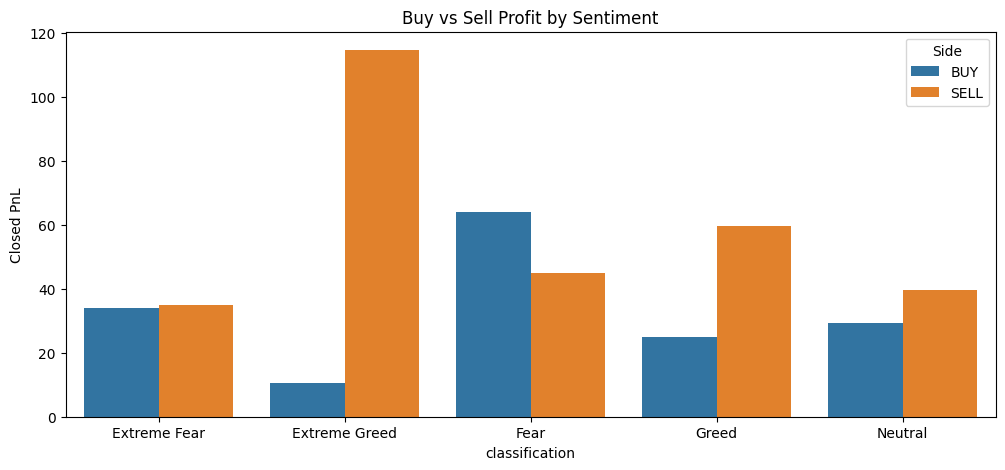

In [83]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=side_profit,
    x='classification',
    y='Closed PnL',
    hue='Side'
)

plt.title('Buy vs Sell Profit by Sentiment')
plt.savefig(
    '../outputs/figures/Buy_vs_Sell_Profit_by_Sentiment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [30]:
merged.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'date',
 'classification',
 'value',
 'Profit_Flag']

In [31]:
corr_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'value'
]

corr = merged[corr_cols].corr()

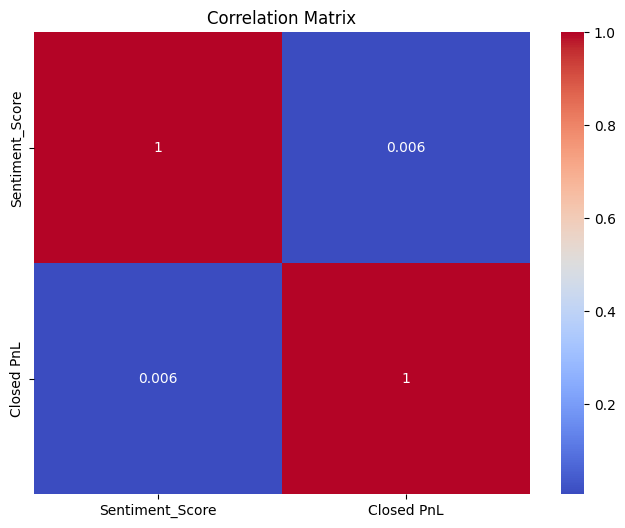

In [84]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.savefig(
    '../outputs/figures/Correlation_Matrix.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [33]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


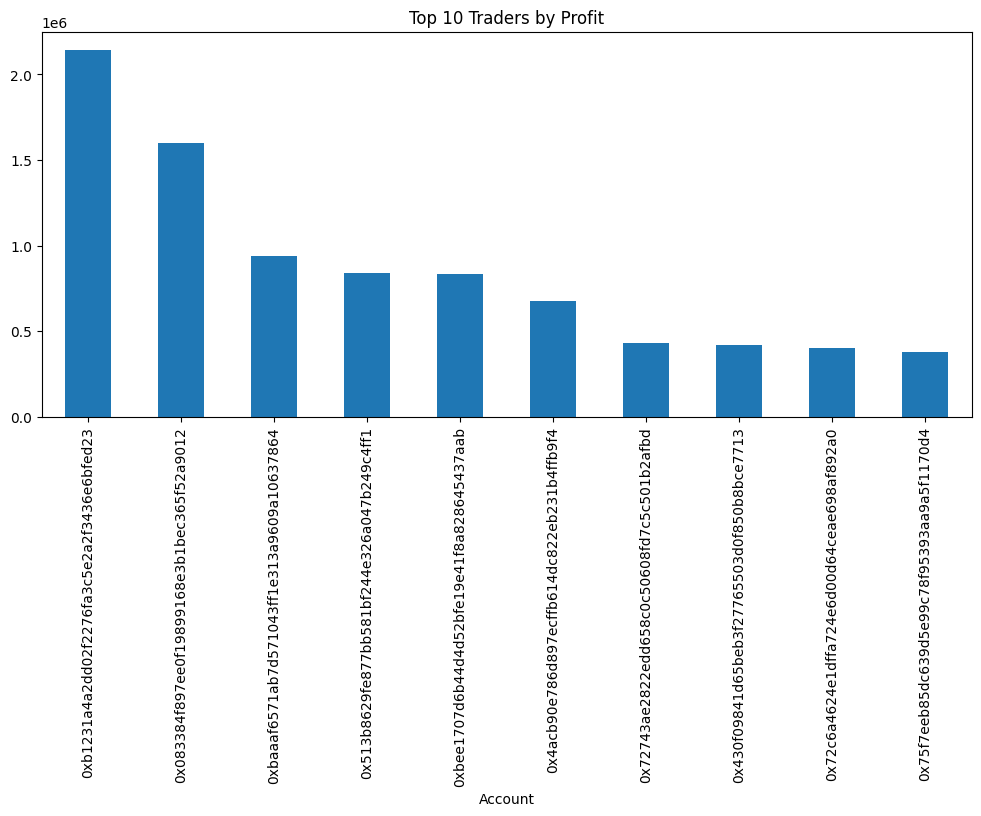

In [85]:
plt.figure(figsize=(12,5))

top_traders.plot(kind='bar')

plt.title('Top 10 Traders by Profit')
plt.savefig(
    '../outputs/figures/Top_10_Traders_by_Profit.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [35]:
side_profit = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean().reset_index()

side_profit

,classification,Side,Closed PnL
0,Extreme Fear,BUY,34.114627
1,Extreme Fear,SELL,34.980106
2,Extreme Greed,BUY,10.498927
3,Extreme Greed,SELL,114.584643
4,Fear,BUY,63.927104
5,Fear,SELL,45.049641
6,Greed,BUY,25.002302
7,Greed,SELL,59.691091
8,Neutral,BUY,29.227429
9,Neutral,SELL,39.456408


In [40]:
sentiment_map = {
    'Extreme Fear': 1,
    'Fear': 2,
    'Neutral': 3,
    'Greed': 4,
    'Extreme Greed': 5
}

merged['Sentiment_Score'] = merged['classification'].map(sentiment_map)

In [41]:
corr = merged[['Sentiment_Score','Closed PnL']].corr()

print(corr)

                 Sentiment_Score  Closed PnL
Sentiment_Score          1.00000     0.00597
Closed PnL               0.00597     1.00000


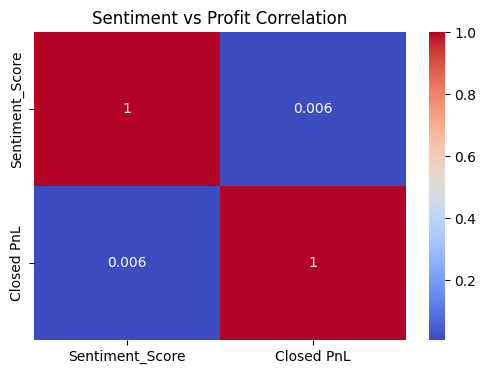

In [86]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Sentiment vs Profit Correlation')
plt.savefig(
    '../outputs/figures/Sentiment_vs_Profit_Correlation.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

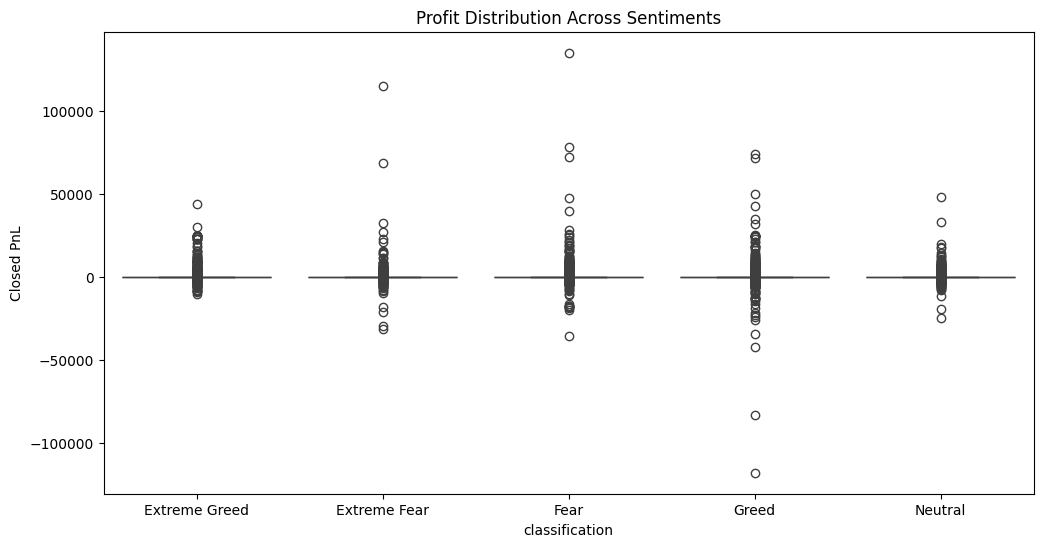

In [87]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('Profit Distribution Across Sentiments')
plt.savefig(
    '../outputs/figures/Profit_Distribution_Across_Sentiments.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [44]:
from scipy.stats import ttest_ind

fear = merged[
    merged['classification'].isin(['Fear','Extreme Fear'])
]['Closed PnL']

greed = merged[
    merged['classification'].isin(['Greed','Extreme Greed'])
]['Closed PnL']

t_stat, p_val = ttest_ind(
    fear,
    greed,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P Value:", p_val)

T Statistic: -0.9875081966653318
P Value: 0.32339495608436164


In [45]:
if p_val < 0.05:
    print("Sentiment significantly affects profitability")
else:
    print("No statistically significant difference")

No statistically significant difference


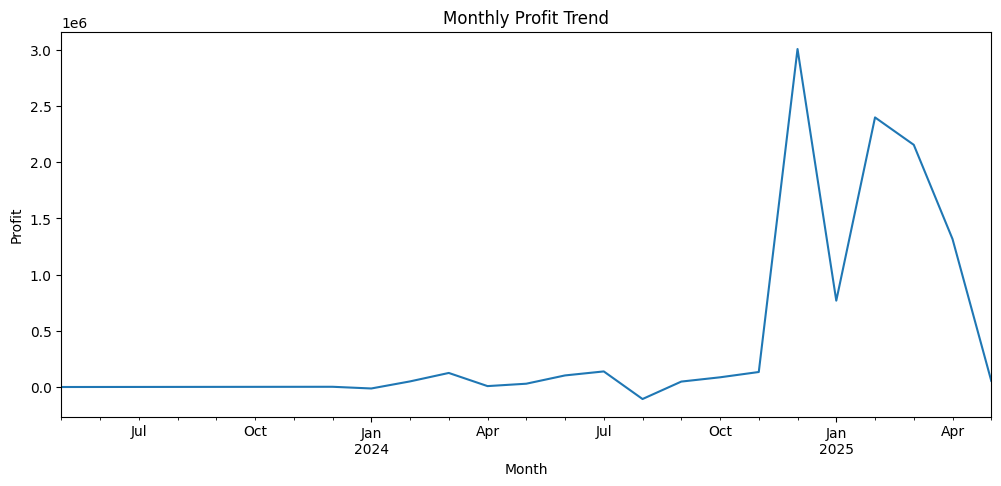

In [88]:
merged['Month'] = merged['Timestamp IST'].dt.to_period('M')

monthly_profit = merged.groupby(
    'Month'
)['Closed PnL'].sum()

monthly_profit.plot(
    figsize=(12,5)
)

plt.title('Monthly Profit Trend')
plt.ylabel('Profit')
plt.savefig(
    '../outputs/figures/Monthly_Profit_Trend.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [51]:
risk = merged.groupby(
    'classification'
)['Closed PnL'].std().sort_values(
    ascending=False
)

print(risk)

classification
Extreme Fear     1136.056091
Greed            1116.028390
Fear              935.355438
Extreme Greed     766.828294
Neutral           517.122220
Name: Closed PnL, dtype: float64


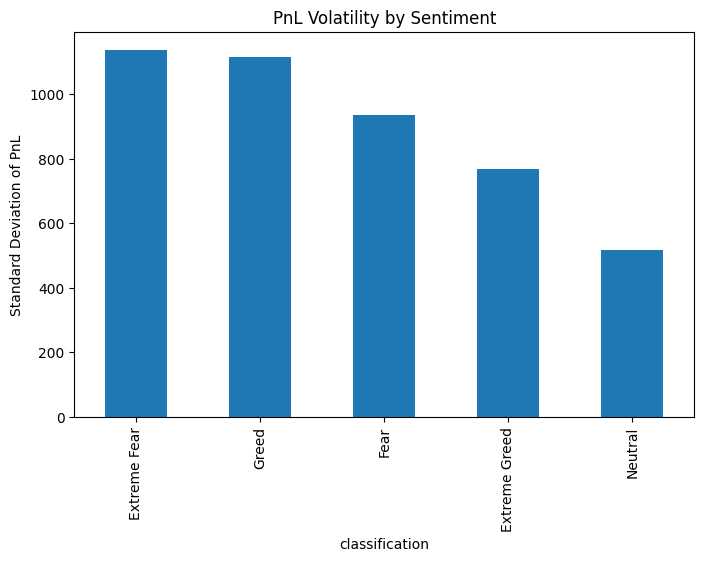

In [89]:
plt.figure(figsize=(8,5))

risk.plot(kind='bar')

plt.title('PnL Volatility by Sentiment')
plt.ylabel('Standard Deviation of PnL')
plt.savefig(
    '../outputs/figures/PnL_Volatility_by_Sentiment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [53]:
from scipy.stats import ttest_ind

fear = merged[
    merged['classification'].isin(['Fear','Extreme Fear'])
]['Closed PnL']

greed = merged[
    merged['classification'].isin(['Greed','Extreme Greed'])
]['Closed PnL']

t_stat, p_val = ttest_ind(
    fear,
    greed,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P Value:", p_val)

T Statistic: -0.9875081966653318
P Value: 0.32339495608436164


In [54]:
summary = pd.DataFrame({
    'Average Profit': merged.groupby('classification')['Closed PnL'].mean(),
    'Total Profit': merged.groupby('classification')['Closed PnL'].sum(),
    'Win Rate (%)': merged.groupby('classification')['Profit_Flag'].mean()*100,
    'Average Trade Size': merged.groupby('classification')['Size USD'].mean()
})

summary = summary.round(2)

summary

,Average Profit,Total Profit,Win Rate (%),Average Trade Size
classification,,,,
Extreme Fear,34.54,739110.25,37.06,5349.73
Extreme Greed,67.89,2715171.31,46.49,3112.25
Fear,54.29,3357155.44,42.08,7816.11
Greed,42.74,2150129.27,38.48,5736.88
Neutral,34.31,1292920.68,39.70,4782.73


In [63]:
import os

print(os.path.exists('../outputs'))
print(os.path.exists('../outputs/tables'))

True
True


In [65]:
import os

os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

In [66]:
summary.to_csv('../outputs/tables/final_summary.csv', index=True)

# Key Findings

1. Extreme Greed produced the highest average profit per trade (~68 PnL).

2. Fear sentiment generated the highest cumulative profit (~3.4 million PnL).

3. Extreme Greed achieved the highest win rate (~46%).

4. Extreme Fear recorded the lowest win rate (~37%).

5. The T-test produced:
   - T Statistic = -0.9875
   - P Value = 0.3234

6. Since p-value > 0.05, profitability differences between Fear and Greed periods are not statistically significant.

7. Market sentiment influences trading behavior but is not a standalone predictor of profitability.

# Recommendations

- Use sentiment as a contextual market indicator rather than a standalone trading signal.

- Combine sentiment indicators with technical indicators and volatility measures.

- Apply stricter risk management during Extreme Fear periods.

- Monitor sentiment shifts to identify changes in market participation and risk appetite.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using over 211,000 Hyperliquid trades.

Results indicate that Extreme Greed periods are associated with higher average profitability and win rates, while Fear periods generate the largest cumulative profits due to increased trading activity.

Statistical testing suggests that sentiment alone does not significantly explain profitability differences, highlighting the importance of additional market and trader-specific factors.

Future work may include predictive modeling using machine learning techniques to forecast profitable trading opportunities based on sentiment and market features.